# Chest X-ray CNN notebook — PyTorch version

This is a PyTorch conversion of the original TensorFlow/Keras notebook.

Notes:
- The custom CNN is converted closely from the original architecture.
- `ResNet152V2` is replaced with `torchvision.models.resnet152`, which is the closest standard PyTorch option.
- The training flow keeps the same overall stages:
  1. Custom CNN training
  2. Frozen pretrained backbone training
  3. Fine-tuning the pretrained model

In [1]:
import os
import glob
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
IMG_SIZE = 224
BATCH = 32
SEED = 42
NUM_EPOCHS = 50

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

Using device: cuda


In [3]:
main_path = "./chest_xray"
train_path = os.path.join(main_path, "train")
test_path = os.path.join(main_path, "test")

train_normal = glob.glob(train_path + "/NORMAL/*.jpeg")
train_pneumonia = glob.glob(train_path + "/PNEUMONIA/*.jpeg")

test_normal = glob.glob(test_path + "/NORMAL/*.jpeg")
test_pneumonia = glob.glob(test_path + "/PNEUMONIA/*.jpeg")

train_list = [x for x in train_normal]
train_list.extend([x for x in train_pneumonia])

df_train = pd.DataFrame(
    np.concatenate([["Normal"] * len(train_normal), ["Pneumonia"] * len(train_pneumonia)]),
    columns=["class"]
)
df_train["image"] = train_list

test_list = [x for x in test_normal]
test_list.extend([x for x in test_pneumonia])

df_test = pd.DataFrame(
    np.concatenate([["Normal"] * len(test_normal), ["Pneumonia"] * len(test_pneumonia)]),
    columns=["class"]
)
df_test["image"] = test_list

print("Train size:", len(df_train))
print("Test size :", len(df_test))
df_train.head()

Train size: 5232
Test size : 624


,class,image
0,Normal,./chest_xray\train/NORMAL\NORMAL-1003233-0001....
1,Normal,./chest_xray\train/NORMAL\NORMAL-1012843-0001....
2,Normal,./chest_xray\train/NORMAL\NORMAL-1014768-0001....
3,Normal,./chest_xray\train/NORMAL\NORMAL-1023731-0001....
4,Normal,./chest_xray\train/NORMAL\NORMAL-1029510-0001....


In [4]:
train_df, val_df = train_test_split(
    df_train,
    test_size=0.20,
    random_state=SEED,
    stratify=df_train["class"]
)

print("Train split:", len(train_df))
print("Val split  :", len(val_df))
train_df.head()

Train split: 4185
Val split  : 1047


,class,image
3566,Pneumonia,./chest_xray\train/PNEUMONIA\BACTERIA-8718799-...
2866,Pneumonia,./chest_xray\train/PNEUMONIA\BACTERIA-6295192-...
2681,Pneumonia,./chest_xray\train/PNEUMONIA\BACTERIA-5615122-...
1199,Normal,./chest_xray\train/NORMAL\NORMAL-9031828-0001....
4619,Pneumonia,./chest_xray\train/PNEUMONIA\VIRUS-5822550-000...


In [5]:
class_to_idx = {"Normal": 0, "Pneumonia": 1}
idx_to_class = {v: k for k, v in class_to_idx.items()}

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image_path = row["image"]
        label = class_to_idx[row["class"]]

        image = Image.open(image_path).convert("RGB")

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)

In [6]:
cnn_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
])

cnn_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

In [7]:
train_ds = XRayDataset(train_df, transform=cnn_train_transform)
val_ds = XRayDataset(val_df, transform=cnn_eval_transform)
test_ds = XRayDataset(df_test, transform=cnn_eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

Train batches: 131
Val batches  : 33
Test batches : 20


In [8]:
class EarlyStopping:
    def __init__(self, patience=5, min_delta=1e-7):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True

In [9]:
def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            logits = model(images)
            loss = criterion(logits, labels)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            running_loss += loss.item() * images.size(0)
            all_labels.extend(labels.cpu().numpy().ravel().astype(int))
            all_preds.extend(preds.cpu().numpy().ravel().astype(int))
            all_probs.extend(probs.cpu().numpy().ravel())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)


def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, scheduler=None, patience=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    early_stopping = EarlyStopping(patience=patience, min_delta=1e-7)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        train_labels = []
        train_preds = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()

            running_loss += loss.item() * images.size(0)
            train_labels.extend(labels.detach().cpu().numpy().ravel().astype(int))
            train_preds.extend(preds.detach().cpu().numpy().ravel().astype(int))

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(train_labels, train_preds)

        val_loss, val_acc, _, _, _ = evaluate_model(model, val_loader, criterion)

        if scheduler is not None:
            scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        early_stopping.step(val_loss, model)
        if early_stopping.should_stop:
            print("Early stopping triggered.")
            break

    if early_stopping.best_state is not None:
        model.load_state_dict(early_stopping.best_state)

    return model, history

In [10]:
class ChestXRayCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(16, 32, kernel_size=3, padding=0),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.2),

            nn.Conv2d(32, 64, kernel_size=3, padding=0),
            nn.Conv2d(64, 64, kernel_size=3, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Dropout(0.4),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feat_dim = self.features(dummy).view(1, -1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(feat_dim, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [11]:
model = ChestXRayCNN().to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    verbose=True
)

model

c:\Users\thoai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


ChestXRayCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.2, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (15): Dropout(p=0.4, inplace=False)

In [12]:
model, history_cnn = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler,
    patience=5
)

Epoch [1/50] Train Loss: 0.4318 | Train Acc: 0.8024 | Val Loss: 0.3144 | Val Acc: 0.8338
Epoch [2/50] Train Loss: 0.2898 | Train Acc: 0.8748 | Val Loss: 0.2468 | Val Acc: 0.8863
Epoch [3/50] Train Loss: 0.2362 | Train Acc: 0.9070 | Val Loss: 0.2022 | Val Acc: 0.9188
Epoch [4/50] Train Loss: 0.2163 | Train Acc: 0.9152 | Val Loss: 0.1625 | Val Acc: 0.9436
Epoch [5/50] Train Loss: 0.2061 | Train Acc: 0.9188 | Val Loss: 0.1674 | Val Acc: 0.9389
Epoch [6/50] Train Loss: 0.1937 | Train Acc: 0.9269 | Val Loss: 0.1460 | Val Acc: 0.9484
Epoch [7/50] Train Loss: 0.1864 | Train Acc: 0.9295 | Val Loss: 0.1353 | Val Acc: 0.9561
Epoch [8/50] Train Loss: 0.1880 | Train Acc: 0.9271 | Val Loss: 0.1269 | Val Acc: 0.9570
Epoch [9/50] Train Loss: 0.1736 | Train Acc: 0.9281 | Val Loss: 0.1350 | Val Acc: 0.9542
Epoch [10/50] Train Loss: 0.1758 | Train Acc: 0.9345 | Val Loss: 0.1275 | Val Acc: 0.9561
Epoch [11/50] Train Loss: 0.1671 | Train Acc: 0.9393 | Val Loss: 0.1451 | Val Acc: 0.9475
Epoch [12/50] Train

In [13]:
val_loss, val_acc, _, _, _ = evaluate_model(model, val_loader, criterion)
print("Val loss:", val_loss)
print("Val accuracy:", val_acc)

test_loss, test_acc, _, _, _ = evaluate_model(model, test_loader, criterion)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Val loss: 0.10605497342474765
Val accuracy: 0.9617956064947469
Test loss: 0.29555237512940014
Test accuracy: 0.8830128205128205


## Pretrained model section

The original notebook uses `tf.keras.applications.ResNet152V2`.
This PyTorch version uses `torchvision.models.resnet152` with ImageNet weights.

In [14]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

pretrained_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

pretrained_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

train_ds_pre = XRayDataset(train_df, transform=pretrained_train_transform)
val_ds_pre = XRayDataset(val_df, transform=pretrained_eval_transform)
test_ds_pre = XRayDataset(df_test, transform=pretrained_eval_transform)

train_loader_pre = DataLoader(train_ds_pre, batch_size=BATCH, shuffle=True, num_workers=0)
val_loader_pre = DataLoader(val_ds_pre, batch_size=BATCH, shuffle=False, num_workers=0)
test_loader_pre = DataLoader(test_ds_pre, batch_size=BATCH, shuffle=False, num_workers=0)

In [15]:
weights = models.ResNet152_Weights.DEFAULT
model_pretrained = models.resnet152(weights=weights)

for param in model_pretrained.parameters():
    param.requires_grad = False

num_features = model_pretrained.fc.in_features
model_pretrained.fc = nn.Sequential(
    nn.Linear(num_features, 128),
    nn.ReLU(inplace=True),
    nn.Dropout(0.1),
    nn.Linear(128, 1),
)

model_pretrained = model_pretrained.to(device)

criterion_pre = nn.BCEWithLogitsLoss()
optimizer_pre = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pretrained.parameters()),
    lr=5e-5
)
scheduler_pre = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_pre,
    mode="min",
    factor=0.2,
    patience=2,
    verbose=True
)

model_pretrained

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to C:\Users\thoai/.cache\torch\hub\checkpoints\resnet152-f82ba261.pth
100%|██████████| 230M/230M [00:05<00:00, 45.5MB/s] 
c:\Users\thoai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
model_pretrained, history_pre_frozen = train_model(
    model_pretrained,
    train_loader_pre,
    val_loader_pre,
    criterion_pre,
    optimizer_pre,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler_pre,
    patience=5
)

Epoch [1/50] Train Loss: 0.5324 | Train Acc: 0.7293 | Val Loss: 0.4128 | Val Acc: 0.8271
Epoch [2/50] Train Loss: 0.3621 | Train Acc: 0.8566 | Val Loss: 0.3009 | Val Acc: 0.9245
Epoch [3/50] Train Loss: 0.2798 | Train Acc: 0.9061 | Val Loss: 0.2404 | Val Acc: 0.9293
Epoch [4/50] Train Loss: 0.2383 | Train Acc: 0.9099 | Val Loss: 0.2046 | Val Acc: 0.9312
Epoch [5/50] Train Loss: 0.2140 | Train Acc: 0.9207 | Val Loss: 0.1922 | Val Acc: 0.9341
Epoch [6/50] Train Loss: 0.1999 | Train Acc: 0.9266 | Val Loss: 0.1770 | Val Acc: 0.9341
Epoch [7/50] Train Loss: 0.1947 | Train Acc: 0.9240 | Val Loss: 0.1637 | Val Acc: 0.9398
Epoch [8/50] Train Loss: 0.1752 | Train Acc: 0.9357 | Val Loss: 0.1591 | Val Acc: 0.9417
Epoch [9/50] Train Loss: 0.1761 | Train Acc: 0.9321 | Val Loss: 0.1580 | Val Acc: 0.9456
Epoch [10/50] Train Loss: 0.1771 | Train Acc: 0.9300 | Val Loss: 0.1486 | Val Acc: 0.9503
Epoch [11/50] Train Loss: 0.1598 | Train Acc: 0.9376 | Val Loss: 0.1437 | Val Acc: 0.9503
Epoch [12/50] Train

In [17]:
val_loss, val_acc, _, _, _ = evaluate_model(model_pretrained, val_loader_pre, criterion_pre)
print("Val loss:", val_loss)
print("Val accuracy:", val_acc)

test_loss, test_acc, _, _, _ = evaluate_model(model_pretrained, test_loader_pre, criterion_pre)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Val loss: 0.1109339813875264
Val accuracy: 0.9570200573065902
Test loss: 0.2547849267243575
Test accuracy: 0.8990384615384616


## Fine-tuning section

The original Keras notebook unfreezes most of the backbone except earlier layers.
In this PyTorch version, we unfreeze `layer4` and the classification head.

In [18]:
for param in model_pretrained.parameters():
    param.requires_grad = False

for param in model_pretrained.layer4.parameters():
    param.requires_grad = True

for param in model_pretrained.fc.parameters():
    param.requires_grad = True

optimizer_finetune = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_pretrained.parameters()),
    lr=2e-6
)
scheduler_finetune = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_finetune,
    mode="min",
    factor=0.2,
    patience=2,
    verbose=True
)

c:\Users\thoai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [19]:
model_pretrained, history_pre_finetune = train_model(
    model_pretrained,
    train_loader_pre,
    val_loader_pre,
    criterion_pre,
    optimizer_finetune,
    num_epochs=NUM_EPOCHS,
    scheduler=scheduler_finetune,
    patience=5
)

Epoch [1/50] Train Loss: 0.1249 | Train Acc: 0.9539 | Val Loss: 0.1108 | Val Acc: 0.9570
Epoch [2/50] Train Loss: 0.1158 | Train Acc: 0.9565 | Val Loss: 0.1068 | Val Acc: 0.9589
Epoch [3/50] Train Loss: 0.1138 | Train Acc: 0.9582 | Val Loss: 0.1099 | Val Acc: 0.9561
Epoch [4/50] Train Loss: 0.1086 | Train Acc: 0.9622 | Val Loss: 0.1212 | Val Acc: 0.9503
Epoch [5/50] Train Loss: 0.1144 | Train Acc: 0.9570 | Val Loss: 0.1102 | Val Acc: 0.9589
Epoch [6/50] Train Loss: 0.1069 | Train Acc: 0.9601 | Val Loss: 0.1052 | Val Acc: 0.9589
Epoch [7/50] Train Loss: 0.1114 | Train Acc: 0.9577 | Val Loss: 0.1052 | Val Acc: 0.9570
Epoch [8/50] Train Loss: 0.1076 | Train Acc: 0.9591 | Val Loss: 0.1081 | Val Acc: 0.9570
Epoch [9/50] Train Loss: 0.1155 | Train Acc: 0.9570 | Val Loss: 0.1038 | Val Acc: 0.9589
Epoch [10/50] Train Loss: 0.1061 | Train Acc: 0.9596 | Val Loss: 0.1084 | Val Acc: 0.9589
Epoch [11/50] Train Loss: 0.1043 | Train Acc: 0.9611 | Val Loss: 0.1050 | Val Acc: 0.9580
Epoch [12/50] Train

In [20]:
val_loss, val_acc, y_val, p_val, prob_val = evaluate_model(model_pretrained, val_loader_pre, criterion_pre)
print("Val loss:", val_loss)
print("Val accuracy:", val_acc)

test_loss, test_acc, y_test, p_test, prob_test = evaluate_model(model_pretrained, test_loader_pre, criterion_pre)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

Val loss: 0.10378769005238725
Val accuracy: 0.958930276981853
Test loss: 0.23907465506822634
Test accuracy: 0.9022435897435898


In [21]:
torch.save(model_pretrained.state_dict(), "baseline_resnet152.pth")
print("Saved to baseline_resnet152.pth")

Saved to baseline_resnet152.pth


In [22]:
def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.title(title + " - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

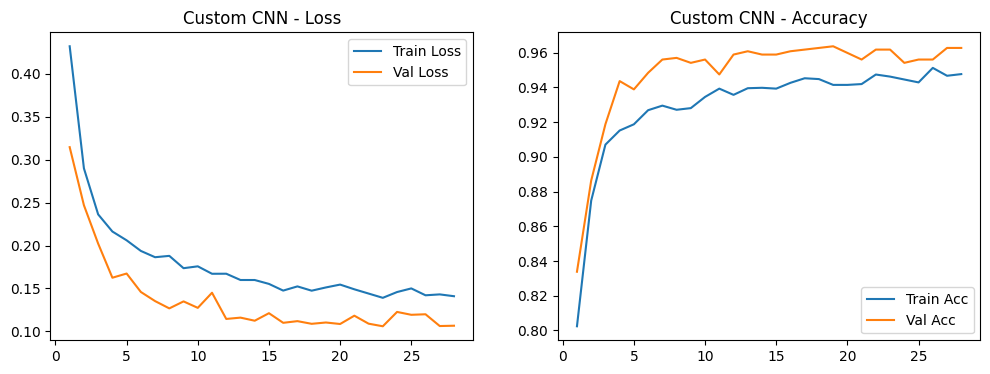

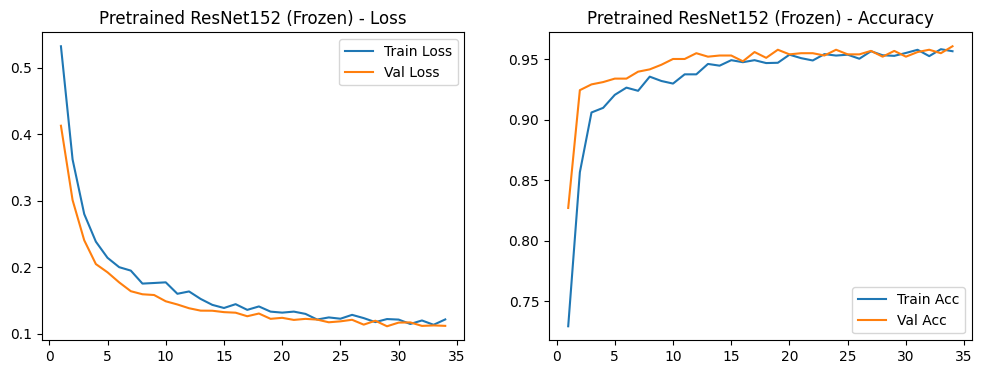

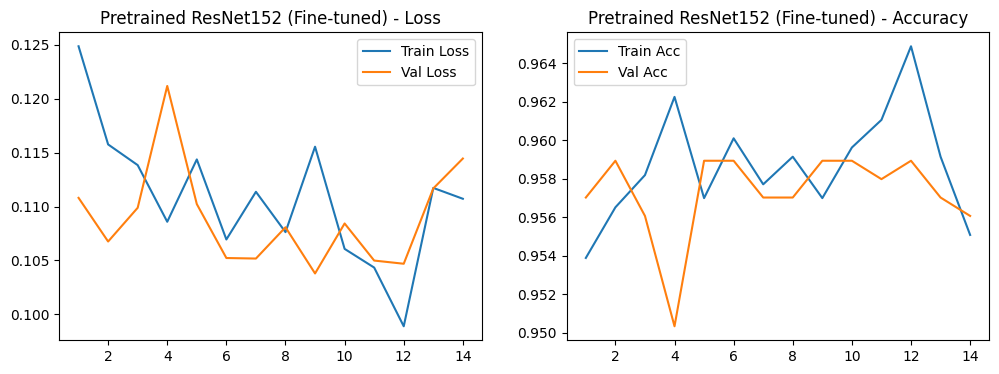

In [23]:
plot_history(history_cnn, title="Custom CNN")
plot_history(history_pre_frozen, title="Pretrained ResNet152 (Frozen)")
plot_history(history_pre_finetune, title="Pretrained ResNet152 (Fine-tuned)")